<a href="https://colab.research.google.com/github/Innocent-Tim/students_performance/blob/main/studentsperformance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 483.8 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#Data Loading & Exploration

##Import Libraries
Load all tools needed for the project

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Load the Dataset
Read the CSV file into a dataframe

In [29]:
df = pd.read_csv("/content/xAPI-Edu-Data.csv")
print("Shape:", df.shape)

Shape: (480, 17)


##First Look
See the first few rows of data

In [ ]:
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


##Column Overview
Check all column names and their data types

In [ ]:
print(df.columns.tolist())
print(df.dtypes)

['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID', 'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays', 'Class']
gender                      object
NationalITy                 object
PlaceofBirth                object
StageID                     object
GradeID                     object
SectionID                   object
Topic                       object
Semester                    object
Relation                    object
raisedhands                  int64
VisITedResources             int64
AnnouncementsView            int64
Discussion                   int64
ParentAnsweringSurvey       object
ParentschoolSatisfaction    object
StudentAbsenceDays          object
Class                       object
dtype: object


#Data Cleaning

##Check Missing Values
Find out if any data is missing

In [ ]:
print(df.isnull().sum())

gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64


##Check Duplicates
Find and remove any duplicate rows

In [30]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 2


##Drop Unnecessary Columns
Remove columns that won't help the model

In [31]:
# Drop unnecessary columns
df = df.drop(columns=['PlaceofBirth', 'SectionID'])
print("Shape after dropping columns:", df.shape)

Shape after dropping columns: (478, 15)


#Statistics (Mean, Mode, Median)

##Descriptive Statistics
Get count, mean, std, min, max for all columns

In [32]:
categorical_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after one-hot encoding:", df.shape)
print("\nData Types after encoding:")
print(df.dtypes)

Shape after one-hot encoding: (478, 47)

Data Types after encoding:
raisedhands                      int64
VisITedResources                 int64
AnnouncementsView                int64
Discussion                       int64
gender_M                          bool
NationalITy_Iran                  bool
NationalITy_Iraq                  bool
NationalITy_Jordan                bool
NationalITy_KW                    bool
NationalITy_Lybia                 bool
NationalITy_Morocco               bool
NationalITy_Palestine             bool
NationalITy_SaudiArabia           bool
NationalITy_Syria                 bool
NationalITy_Tunis                 bool
NationalITy_USA                   bool
NationalITy_lebanon               bool
NationalITy_venzuela              bool
StageID_MiddleSchool              bool
StageID_lowerlevel                bool
GradeID_G-04                      bool
GradeID_G-05                      bool
GradeID_G-06                      bool
GradeID_G-07                      b

In [ ]:
df.head()


,raisedhands,VisITedResources,AnnouncementsView,Discussion,gender_M,NationalITy_Iran,NationalITy_Iraq,NationalITy_Jordan,NationalITy_KW,NationalITy_Lybia,...,Topic_Quran,Topic_Science,Topic_Spanish,Semester_S,Relation_Mum,ParentAnsweringSurvey_Yes,ParentschoolSatisfaction_Good,StudentAbsenceDays_Under-7,Class_L,Class_M
0,15,16,2,20,True,False,False,False,True,False,...,False,False,False,False,False,True,True,True,False,True
1,20,20,3,25,True,False,False,False,True,False,...,False,False,False,False,False,True,True,True,False,True
2,10,7,0,30,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
3,30,25,5,35,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
4,40,50,12,50,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True


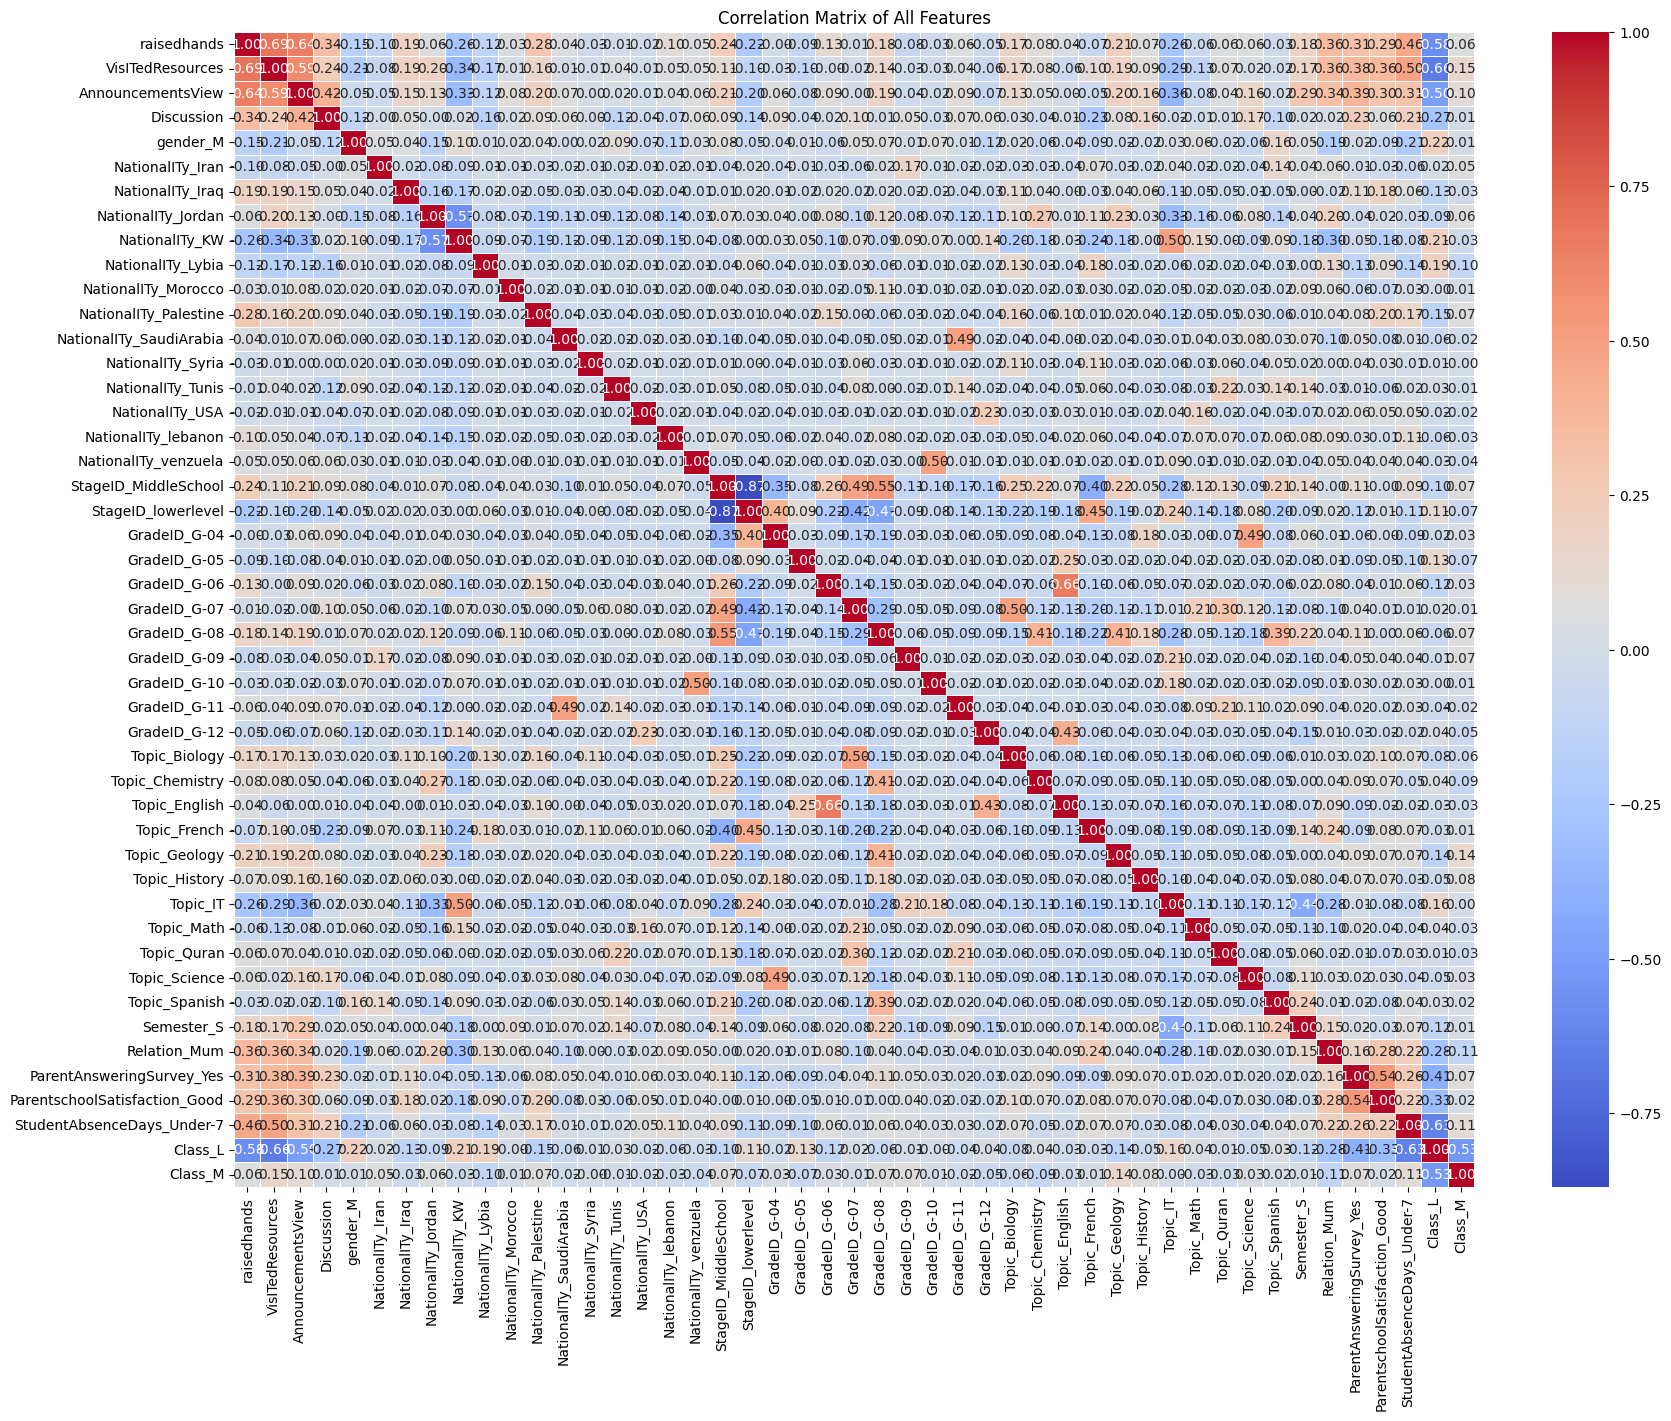

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix of All Features')
plt.show()

## Dimensionality Reduction with PCA

Before applying PCA, it's important to scale the data to ensure that features with larger values do not dominate the principal components.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the entire DataFrame (since all columns are now numeric after one-hot encoding)
X_scaled = scaler.fit_transform(df)

print("Shape of scaled data:", X_scaled.shape)

Shape of scaled data: (478, 47)


Now, let's apply Principal Component Analysis (PCA) to reduce the dimensionality of the scaled data. We'll examine the explained variance ratio to understand how much information each principal component captures.

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA (e.g., to retain 95% of the variance)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Original number of features:", X_scaled.shape[1])
print("Number of components selected by PCA (95% variance):", pca.n_components_)

Original number of features: 47
Number of components selected by PCA (95% variance): 35


We can also visualize the explained variance ratio per component and the cumulative explained variance to help decide on the number of components manually if needed.

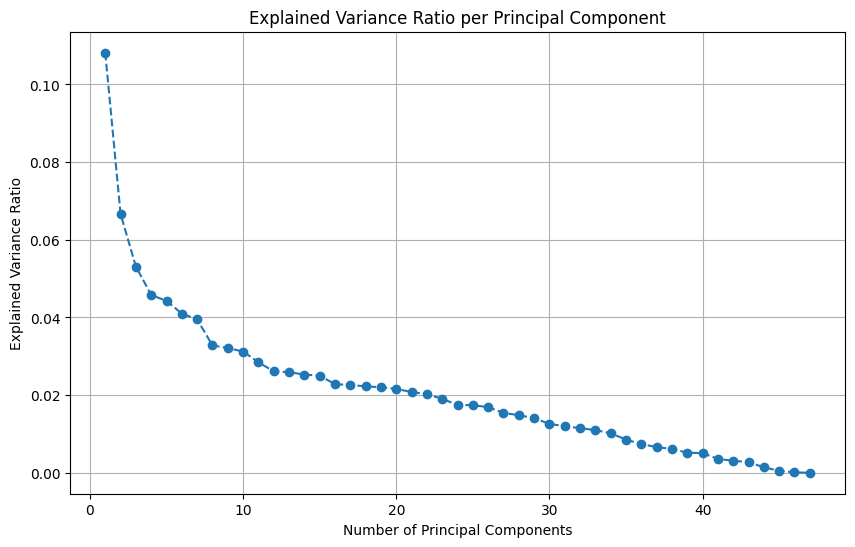

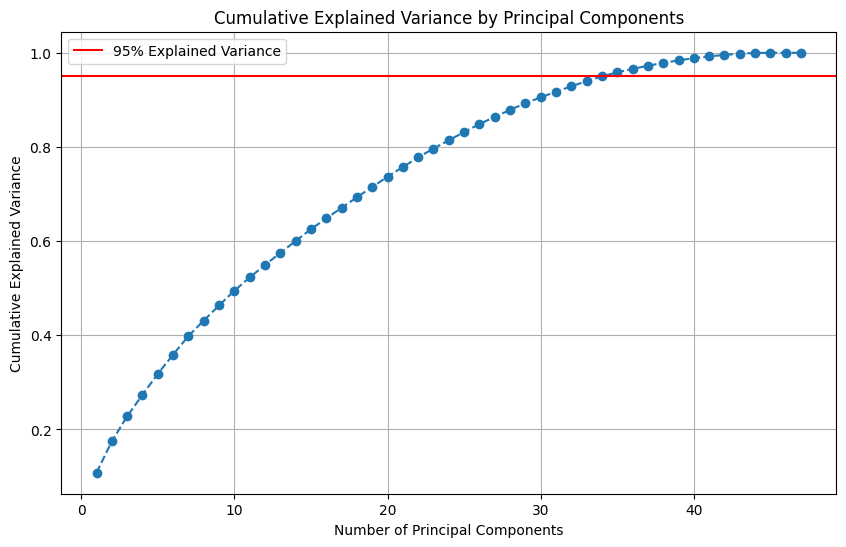

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

# Initialize PCA without specifying n_components to get all components
pca_full = PCA()
pca_full.fit(X_scaled)

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), pca_full.explained_variance_ratio_, marker='o', linestyle='--')
plt.title('Explained Variance Ratio per Principal Component')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

# Plot the cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), np.cumsum(pca_full.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance')
plt.legend(loc='best')
plt.show()

In [ ]:
df.shape
df.head()

,raisedhands,VisITedResources,AnnouncementsView,Discussion,gender_M,NationalITy_Iran,NationalITy_Iraq,NationalITy_Jordan,NationalITy_KW,NationalITy_Lybia,...,Topic_Quran,Topic_Science,Topic_Spanish,Semester_S,Relation_Mum,ParentAnsweringSurvey_Yes,ParentschoolSatisfaction_Good,StudentAbsenceDays_Under-7,Class_L,Class_M
0,15,16,2,20,True,False,False,False,True,False,...,False,False,False,False,False,True,True,True,False,True
1,20,20,3,25,True,False,False,False,True,False,...,False,False,False,False,False,True,True,True,False,True
2,10,7,0,30,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
3,30,25,5,35,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
4,40,50,12,50,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True


In [16]:
pip install mlflow

## Export Cleaned Data for Power BI

Now that the data has been cleaned, duplicated values removed, unnecessary columns dropped, and categorical features one-hot encoded, we can export this prepared dataset to a CSV file. This CSV file can then be easily imported into Power BI for visualization and dashboard creation.

In [33]:
# Export the cleaned DataFrame to a CSV file
output_file_path = '/content/cleaned_xAPI_Edu_Data.csv'
df.to_csv(output_file_path, index=False)

print(f"Cleaned data exported successfully to: {output_file_path}")

Cleaned data exported successfully to: /content/cleaned_xAPI_Edu_Data.csv


### Steps to Load Data into Power BI Desktop:

1.  **Open Power BI Desktop.**
2.  Go to the **Home** tab and click **Get data**.
3.  Select **Text/CSV** from the list of data sources and click **Connect**.
4.  Navigate to the `/content/` directory (or wherever you downloaded the file) and select `cleaned_xAPI_Edu_Data.csv`.
5.  In the preview window, ensure the data looks correct. Power BI should automatically detect the delimiter and data types. Click **Load**.

Once loaded, you can start building your visual dashboard using the columns from the `cleaned_xAPI_Edu_Data` table in the Fields pane.

#Model Training


## Prepare Data for Model Training

First, we need to separate the features (X) from the target variable (y). Based on the dataset's context, 'Class_L' and 'Class_M' (representing 'Low' and 'Medium' performance classes after one-hot encoding for the 'Class' column) are suitable target variables. We will choose one of these and then split the data into training and testing sets.

In [34]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Assuming 'Class_M' and 'Class_L' are the one-hot encoded representations of the original 'Class' column
# We'll use 'Class_M' as the target for binary classification (e.g., Is the student in class M or not?)
# The remaining columns are features.

# Drop the 'Class_L' and 'Class_M' from features if they are used as target or if we only need one
# Let's consider 'Class_M' as our target, aiming to predict if a student belongs to the 'M' class.

X = df.drop(columns=['Class_L', 'Class_M'])
y = df['Class_M'] # Target variable: True if student is in Class 'M', False otherwise

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (334, 45)
X_test shape: (144, 45)
y_train shape: (334,)
y_test shape: (144,)


## Train a Classification Model

We will start with a simple Logistic Regression model, which is a good baseline for binary classification tasks. After training, we will evaluate its performance using common classification metrics like accuracy, precision, recall, and F1-score.

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Model: Logistic Regression")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model: Logistic Regression
Accuracy: 0.5903
Precision: 0.5455
Recall: 0.4688
F1-Score: 0.5042

Classification Report:
              precision    recall  f1-score   support

       False       0.62      0.69      0.65        80
        True       0.55      0.47      0.50        64

    accuracy                           0.59       144
   macro avg       0.58      0.58      0.58       144
weighted avg       0.59      0.59      0.59       144



## Train a Random Forest Classifier

Let's try another classification model, the Random Forest Classifier, to see if we can improve performance. Random Forest is an ensemble learning method that builds multiple decision trees and merges their predictions to get a more accurate and stable prediction.

In [36]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Model: Random Forest Classifier")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

Model: Random Forest Classifier
Accuracy: 0.7222
Precision: 0.6875
Recall: 0.6875
F1-Score: 0.6875

Classification Report (Random Forest):
              precision    recall  f1-score   support

       False       0.75      0.75      0.75        80
        True       0.69      0.69      0.69        64

    accuracy                           0.72       144
   macro avg       0.72      0.72      0.72       144
weighted avg       0.72      0.72      0.72       144



## Train an XGBoost Classifier

Now, let's train a powerful gradient boosting model, XGBoost (Extreme Gradient Boosting), which is known for its speed and performance in structured data tasks.

In [37]:
from xgboost import XGBClassifier

# Initialize and train the XGBoost Classifier model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss') # Suppress warning for use_label_encoder
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the XGBoost model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print(f"Model: XGBoost Classifier")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")
print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb))

Model: XGBoost Classifier
Accuracy: 0.6944
Precision: 0.6429
Recall: 0.7031
F1-Score: 0.6716

Classification Report (XGBoost):
              precision    recall  f1-score   support

       False       0.74      0.69      0.71        80
        True       0.64      0.70      0.67        64

    accuracy                           0.69       144
   macro avg       0.69      0.70      0.69       144
weighted avg       0.70      0.69      0.70       144



/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [15:05:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Save the Best Model using Pickle

To save the best-performing trained model (Random Forest Classifier in this case) for future use without needing to retrain it, we can use the `pickle` module. This serializes the Python object (our model) into a byte stream, which can then be saved to a file.

In [40]:
import pickle

# Define the filename for the pickle file
pickle_filename = 'random_forest_model.pkl'

# Save the Random Forest model to the pickle file
with open(pickle_filename, 'wb') as file:
    pickle.dump(rf_model, file)

print(f"Random Forest model successfully saved to {pickle_filename}")

Random Forest model successfully saved to random_forest_model.pkl
